# RPS (Requests Per Second) Forecasting by Endpoints with CatBoost (Time Series K-Fold CV)
Прогнозирование RPS для разных ручек на 2-3 минуты с k-fold кросс-валидацией для временных рядов

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load and combine RPS data from multiple endpoints
import os

rps_files = [
    '../data/users__rps.csv',
    '../data/accounts__rps.csv',
    '../data/transfers__rps.csv'
]

dfs = []
for file in rps_files:
    if os.path.exists(file):
        df_temp = pd.read_csv(file)
        dfs.append(df_temp)
        print(f"Loaded {file}: {df_temp.shape}")

# Combine all RPS data
df = pd.concat(dfs, ignore_index=True)
df = df.sort_values('timestamp').reset_index(drop=True)

print(f"\nCombined Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nUnique handlers: {df['handler'].nunique()}")
print(f"Handlers: {df['handler'].unique()}")
print(f"\nRPS stats:\n{df['value'].describe()}")

Loaded ../data/users__rps.csv: (30134, 4)
Loaded ../data/accounts__rps.csv: (30134, 4)
Loaded ../data/transfers__rps.csv: (30134, 4)

Combined Shape: (90402, 4)
Columns: ['timestamp', 'datetime_utc', 'handler', 'value']

Unique handlers: 3
Handlers: ['/users/' '/transfers/' '/accounts/']

RPS stats:
count    90402.000000
mean        11.067484
std         11.944055
min          0.000000
25%          0.318644
50%          2.918644
75%         22.566102
max         49.020690
Name: value, dtype: float64


In [26]:
# Encode categorical handler column
le = LabelEncoder()
df['handler_encoded'] = le.fit_transform(df['handler'])

handler_mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Handler encoding:")
for handler, code in sorted(handler_mapping.items(), key=lambda x: x[1]):
    print(f"  {handler}: {code}")

Handler encoding:
  /accounts/: 0
  /transfers/: 1
  /users/: 2


In [27]:
# 2-3 minutes = 8-12 points (at 15-second intervals)
FORECAST_HORIZON = 10  # 10 * 15 sec = 2.5 minutes

# Create lagged features grouped by handler
def create_features(df, horizon=FORECAST_HORIZON, lags=[1, 2, 3, 4, 5, 8, 12, 16, 20]):
    df = df.copy()
    
    # Create features per handler (to maintain temporal consistency within each endpoint)
    for handler in df['handler'].unique():
        mask = df['handler'] == handler
        handler_idx = df.loc[mask].index
        
        # Lag features
        for lag in lags:
            df.loc[mask, f'rps_lag_{lag}'] = df.loc[mask, 'value'].shift(lag).values
        
        # Rolling statistics
        for window in [4, 8, 12]:
            df.loc[mask, f'rps_rolling_mean_{window}'] = df.loc[mask, 'value'].rolling(window).mean().values
            df.loc[mask, f'rps_rolling_std_{window}'] = df.loc[mask, 'value'].rolling(window).std().values
            df.loc[mask, f'rps_rolling_min_{window}'] = df.loc[mask, 'value'].rolling(window).min().values
            df.loc[mask, f'rps_rolling_max_{window}'] = df.loc[mask, 'value'].rolling(window).max().values
    
    # Target: RPS value in FORECAST_HORIZON steps
    for handler in df['handler'].unique():
        mask = df['handler'] == handler
        df.loc[mask, 'rps_target'] = df.loc[mask, 'value'].shift(-horizon).values
    
    return df

df_features = create_features(df, horizon=FORECAST_HORIZON)
print(f"Features created. Shape: {df_features.shape}")

Features created. Shape: (90402, 27)


In [28]:
# Remove rows with NaN values
df_clean = df_features.dropna().reset_index(drop=True)
print(f"After removing NaN: {df_clean.shape}")
print(f"Removed {df_features.shape[0] - df_clean.shape[0]} rows")

# Time series k-fold cross-validation (respects temporal order)
from sklearn.model_selection import TimeSeriesSplit

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

print(f"\n🎯 Time Series {n_splits}-Fold Cross-Validation:")
print(f"{'Fold':>6} {'Train_Start':>19} {'Train_End':>19} {'Test_Start':>19} {'Test_End':>19} {'Train':>8} {'Test':>8}")
print("-" * 110)

from datetime import datetime
splits = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(df_clean)):
    splits.append((train_idx, test_idx))

    train_times = pd.to_datetime(df_clean.iloc[train_idx]['timestamp'], unit='s')
    test_times = pd.to_datetime(df_clean.iloc[test_idx]['timestamp'], unit='s')

    print(f"{fold+1:>6} {str(train_times.min()):>19} {str(train_times.max()):>19} {str(test_times.min()):>19} {str(test_times.max()):>19} {len(train_idx):>8} {len(test_idx):>8}")

print("-" * 110)

After removing NaN: (90312, 27)
Removed 90 rows

🎯 Time Series 5-Fold Cross-Validation:
  Fold         Train_Start           Train_End          Test_Start            Test_End    Train     Test
--------------------------------------------------------------------------------------------------------------
     1 2026-05-25 18:47:00 2026-05-26 15:41:15 2026-05-26 15:41:15 2026-05-27 12:35:30    15052    15052
     2 2026-05-25 18:47:00 2026-05-27 12:35:30 2026-05-27 12:35:30 2026-05-28 09:29:45    30104    15052
     3 2026-05-25 18:47:00 2026-05-28 09:29:45 2026-05-28 09:30:00 2026-05-29 06:24:15    45156    15052
     4 2026-05-25 18:47:00 2026-05-29 06:24:15 2026-05-29 06:24:15 2026-05-30 03:18:30    60208    15052
     5 2026-05-25 18:47:00 2026-05-30 03:18:30 2026-05-30 03:18:30 2026-05-31 00:12:45    75260    15052
--------------------------------------------------------------------------------------------------------------


In [29]:
# Feature selection
lag_features = [col for col in df_clean.columns if 'rps_lag' in col or 'rps_rolling' in col]
feature_cols = lag_features + ['handler_encoded']  # Include handler as categorical feature

print(f"Numerical features: {len(lag_features)}")
print(f"Total features: {len(feature_cols)}")
print(f"Total data points: {len(df_clean)}")
print(f"\nData points per handler:")
print(df_clean['handler'].value_counts().sort_index())

Numerical features: 21
Total features: 22
Total data points: 90312

Data points per handler:
handler
/accounts/     30104
/transfers/    30104
/users/        30104
Name: count, dtype: int64


In [30]:
# Train CatBoost model using k-fold cross-validation
fold_results = []
models = []

print("\n" + "="*80)
print("TRAINING MODELS WITH TIME SERIES K-FOLD CROSS-VALIDATION")
print("="*80)

categorical_features = ['handler_encoded']

for fold, (train_idx, test_idx) in enumerate(splits):
    print(f"\n🔄 Fold {fold + 1}/{n_splits}")
    
    X_train = df_clean.iloc[train_idx][feature_cols]
    y_train = df_clean.iloc[train_idx]['rps_target']
    
    X_test = df_clean.iloc[test_idx][feature_cols]
    y_test = df_clean.iloc[test_idx]['rps_target']
    
    train_pool = Pool(X_train, y_train, cat_features=categorical_features)
    test_pool = Pool(X_test, y_test, cat_features=categorical_features)
    
    model = CatBoostRegressor(
        iterations=500,
        learning_rate=0.05,
        depth=7,
        loss_function='MAE',
        eval_metric='MAE',
        verbose=0,
        random_state=42,
        task_type='CPU'
    )
    
    model.fit(train_pool, eval_set=test_pool)
    models.append(model)
    
    # Evaluate
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    
    fold_results.append({
        'fold': fold + 1,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'test_rmse': test_rmse,
        'test_r2': test_r2,
        'train_idx': train_idx,
        'test_idx': test_idx,
        'y_test': y_test,
        'y_pred_test': y_pred_test
    })
    
    print(f"  Train MAE: {train_mae:.6f}")
    print(f"  Test MAE:  {test_mae:.6f}")
    print(f"  Test RMSE: {test_rmse:.6f}")
    print(f"  Test R²:   {test_r2:.4f}")

print("\n" + "="*80)


TRAINING MODELS WITH TIME SERIES K-FOLD CROSS-VALIDATION

🔄 Fold 1/5
  Train MAE: 0.284841
  Test MAE:  0.491916
  Test RMSE: 1.064629
  Test R²:   0.9929

🔄 Fold 2/5
  Train MAE: 0.327252
  Test MAE:  0.436804
  Test RMSE: 0.954107
  Test R²:   0.9947

🔄 Fold 3/5
  Train MAE: 0.340912
  Test MAE:  0.443888
  Test RMSE: 1.075117
  Test R²:   0.9921

🔄 Fold 4/5
  Train MAE: 0.349513
  Test MAE:  0.401460
  Test RMSE: 0.817333
  Test R²:   0.9953

🔄 Fold 5/5
  Train MAE: 0.355912
  Test MAE:  0.484374
  Test RMSE: 1.001396
  Test R²:   0.9886



In [31]:
# Detailed analysis of time series k-fold splits
print("\n" + "="*80)
print("DETAILED ANALYSIS OF TIME SERIES K-FOLD SPLITS")
print("="*80)

results_df = pd.DataFrame(fold_results)

print("\n📊 CROSS-VALIDATION RESULTS:")
print(results_df[['fold', 'train_mae', 'test_mae', 'test_rmse', 'test_r2']].to_string(index=False))

print("\n📈 AVERAGED METRICS:")
print(f"  Average Train MAE:  {results_df['train_mae'].mean():.6f}")
print(f"  Average Test MAE:   {results_df['test_mae'].mean():.6f}")
print(f"  Average Test RMSE:  {results_df['test_rmse'].mean():.6f}")
print(f"  Average Test R²:    {results_df['test_r2'].mean():.4f}")
print(f"\n  Std Dev Test MAE:   {results_df['test_mae'].std():.6f}")
print(f"  Std Dev Test R²:    {results_df['test_r2'].std():.4f}")

print("\n" + "="*80)


DETAILED ANALYSIS OF TIME SERIES K-FOLD SPLITS

📊 CROSS-VALIDATION RESULTS:
 fold  train_mae  test_mae  test_rmse  test_r2
    1   0.284841  0.491916   1.064629 0.992896
    2   0.327252  0.436804   0.954107 0.994669
    3   0.340912  0.443888   1.075117 0.992097
    4   0.349513  0.401460   0.817333 0.995280
    5   0.355912  0.484374   1.001396 0.988638

📈 AVERAGED METRICS:
  Average Train MAE:  0.331686
  Average Test MAE:   0.451689
  Average Test RMSE:  0.982516
  Average Test R²:    0.9927

  Std Dev Test MAE:   0.037054
  Std Dev Test R²:    0.0026



In [32]:
# Train final model on full data for feature importance and predictions
print("\n🔄 Training final model on entire dataset for inference...")

train_pool = Pool(df_clean[feature_cols], df_clean['rps_target'], cat_features=categorical_features)

final_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=7,
    loss_function='MAE',
    eval_metric='MAE',
    verbose=0,
    random_state=42,
    task_type='CPU'
)

final_model.fit(train_pool)
print("✓ Final model trained on full data")


🔄 Training final model on entire dataset for inference...
✓ Final model trained on full data


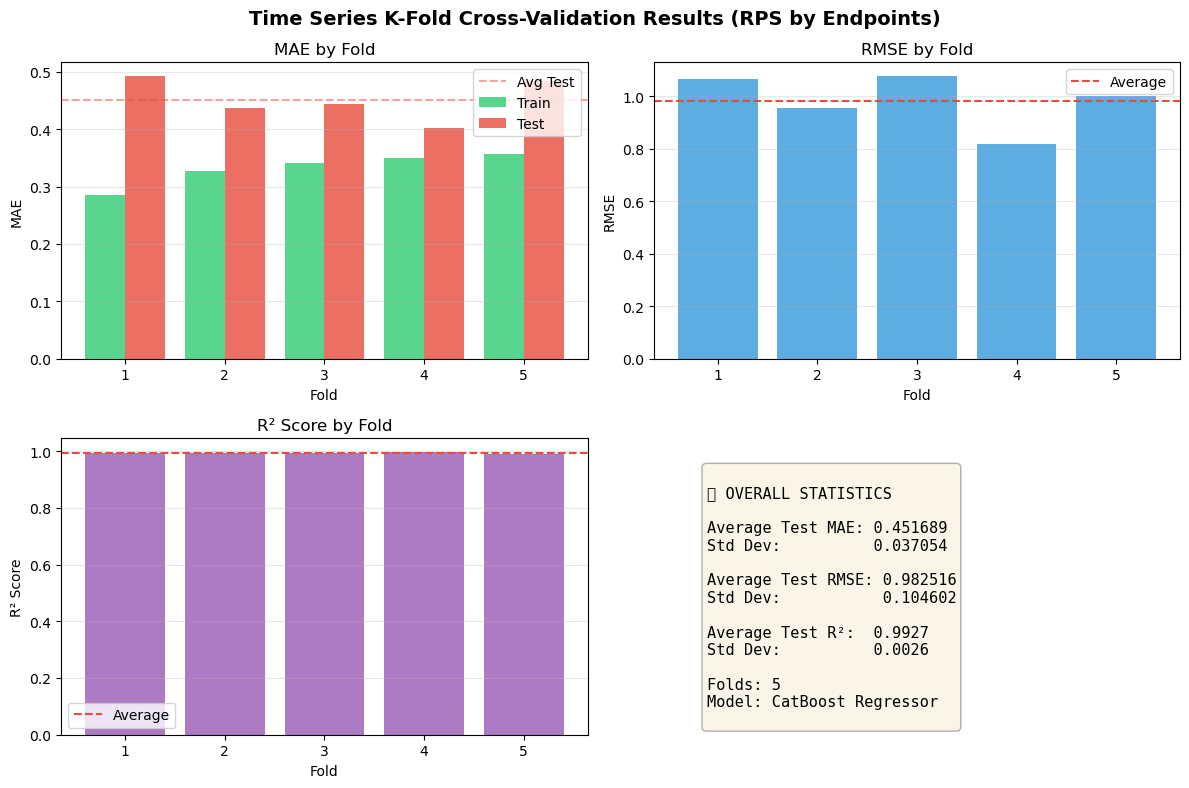

In [33]:
# Visualize cross-validation results
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Time Series K-Fold Cross-Validation Results (RPS by Endpoints)', fontsize=14, fontweight='bold')

folds = results_df['fold']
x_pos = np.arange(len(folds))

# MAE comparison
axes[0, 0].bar(x_pos - 0.2, results_df['train_mae'], 0.4, label='Train', alpha=0.8, color='#2ecc71')
axes[0, 0].bar(x_pos + 0.2, results_df['test_mae'], 0.4, label='Test', alpha=0.8, color='#e74c3c')
axes[0, 0].axhline(results_df['test_mae'].mean(), color='#e74c3c', linestyle='--', alpha=0.5, label='Avg Test')
axes[0, 0].set_xlabel('Fold')
axes[0, 0].set_ylabel('MAE')
axes[0, 0].set_title('MAE by Fold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels(folds)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# RMSE
axes[0, 1].bar(x_pos, results_df['test_rmse'], alpha=0.8, color='#3498db')
axes[0, 1].axhline(results_df['test_rmse'].mean(), color='#e74c3c', linestyle='--', label='Average')
axes[0, 1].set_xlabel('Fold')
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_title('RMSE by Fold')
axes[0, 1].set_xticks(x_pos)
axes[0, 1].set_xticklabels(folds)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3, axis='y')

# R² Score
axes[1, 0].bar(x_pos, results_df['test_r2'], alpha=0.8, color='#9b59b6')
axes[1, 0].axhline(results_df['test_r2'].mean(), color='#e74c3c', linestyle='--', label='Average')
axes[1, 0].set_xlabel('Fold')
axes[1, 0].set_ylabel('R² Score')
axes[1, 0].set_title('R² Score by Fold')
axes[1, 0].set_xticks(x_pos)
axes[1, 0].set_xticklabels(folds)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')

# Overall statistics
axes[1, 1].axis('off')
stats_text = f"""
📊 OVERALL STATISTICS

Average Test MAE: {results_df['test_mae'].mean():.6f}
Std Dev:          {results_df['test_mae'].std():.6f}

Average Test RMSE: {results_df['test_rmse'].mean():.6f}
Std Dev:           {results_df['test_rmse'].std():.6f}

Average Test R²:  {results_df['test_r2'].mean():.4f}
Std Dev:          {results_df['test_r2'].std():.4f}

Folds: {n_splits}
Model: CatBoost Regressor
"""
axes[1, 1].text(0.1, 0.9, stats_text, transform=axes[1, 1].transAxes, fontsize=11,
                verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()


Top 15 Important Features:
            feature  importance
         rps_lag_12   15.291757
  rps_rolling_min_8   14.915856
          rps_lag_1    8.886263
  rps_rolling_min_4    8.421836
 rps_rolling_max_12    6.843913
 rps_rolling_min_12    6.592155
rps_rolling_mean_12    6.145183
         rps_lag_20    5.490370
         rps_lag_16    4.670582
          rps_lag_5    4.420145
 rps_rolling_mean_8    3.047021
          rps_lag_2    2.636978
 rps_rolling_std_12    2.277791
  rps_rolling_std_4    2.126468
 rps_rolling_mean_4    1.850596


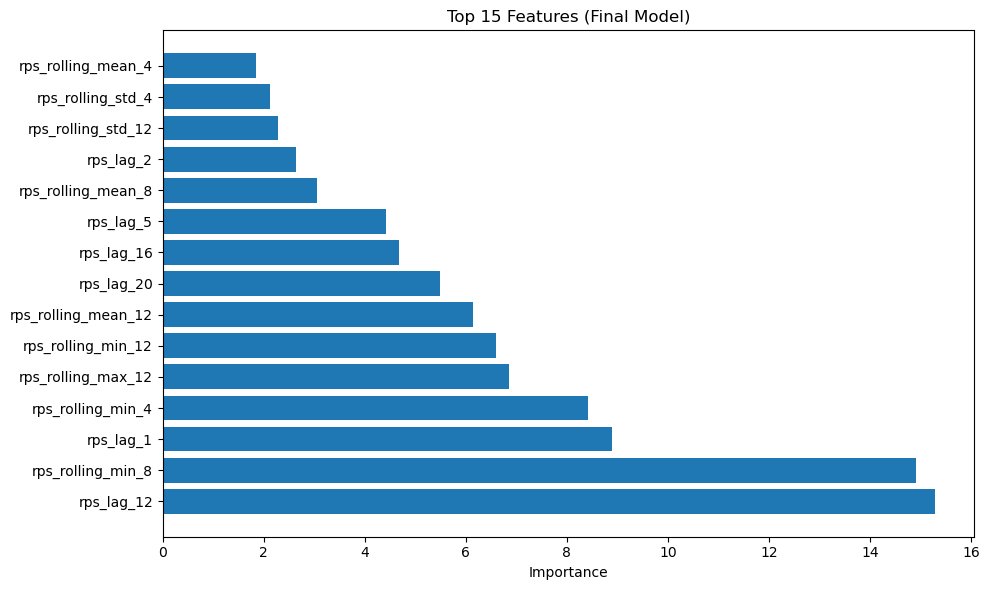

In [34]:
# Feature importance from final model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': final_model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15).to_string(index=False))

plt.figure(figsize=(10, 6))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 15 Features (Final Model)')
plt.tight_layout()
plt.show()

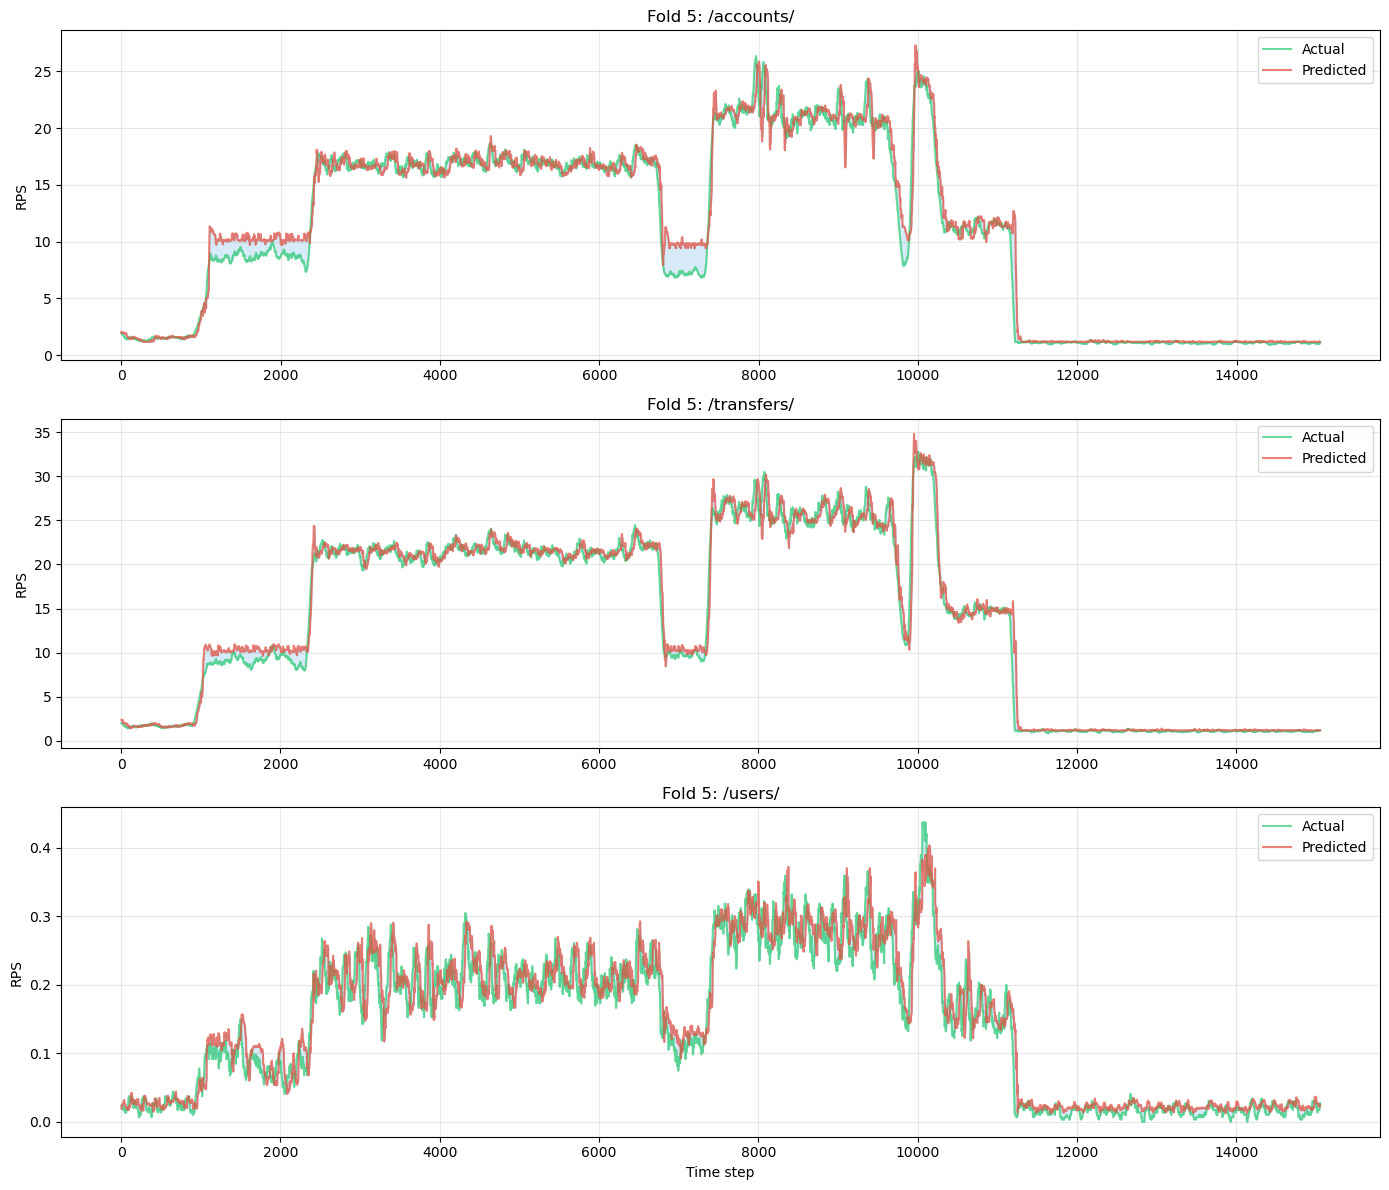


Prediction error distribution by handler (Fold 5 test set):

  /accounts/:
    Min error: 0.000052
    Median error: 0.331380
    Max error: 10.984651
    95th percentile: 2.656136

  /transfers/:
    Min error: 0.000105
    Median error: 0.348882
    Max error: 10.147953
    95th percentile: 2.347414

  /users/:
    Min error: 0.000001
    Median error: 0.014308
    Max error: 0.129424
    95th percentile: 0.064663


In [35]:
# Visualization: predictions vs actual by handler
last_fold_result = fold_results[-1]
y_test_last = last_fold_result['y_test']
y_pred_last = last_fold_result['y_pred_test']
test_idx = last_fold_result['test_idx']

test_handlers = df_clean.iloc[test_idx]['handler'].values

# Plot by handler
handlers = df_clean.iloc[test_idx]['handler'].unique()
fig, axes = plt.subplots(len(handlers), 1, figsize=(14, 4 * len(handlers)))

if len(handlers) == 1:
    axes = [axes]

for idx, handler in enumerate(sorted(handlers)):
    mask = test_handlers == handler
    range_vals = np.where(mask)[0]
    
    axes[idx].plot(range_vals, y_test_last.values[mask], label='Actual', alpha=0.7, linewidth=1.5, color='#2ecc71')
    axes[idx].plot(range_vals, y_pred_last[mask], label='Predicted', alpha=0.7, linewidth=1.5, color='#e74c3c')
    axes[idx].fill_between(range_vals, y_test_last.values[mask], y_pred_last[mask], alpha=0.2, color='#3498db')
    axes[idx].set_title(f"Fold {last_fold_result['fold']}: {handler}")
    axes[idx].set_ylabel('RPS')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
plt.tight_layout()
plt.show()

print(f"\nPrediction error distribution by handler (Fold {last_fold_result['fold']} test set):")
for handler in sorted(handlers):
    mask = test_handlers == handler
    errors = np.abs(y_test_last.values[mask] - y_pred_last[mask])
    print(f"\n  {handler}:")
    print(f"    Min error: {errors.min():.6f}")
    print(f"    Median error: {np.median(errors):.6f}")
    print(f"    Max error: {errors.max():.6f}")
    print(f"    95th percentile: {np.percentile(errors, 95):.6f}")

In [36]:
# Save final model
final_model.save_model('../models/rps_forecast_model.cbm')
print("✓ Model saved as 'rps_forecast_model.cbm'")

import json
with open('../models/rps_model_config.json', 'w') as f:
    # Convert numpy int64 to int for JSON serialization
    handler_mapping_json = {k: int(v) for k, v in handler_mapping.items()}
    json.dump({
        'feature_cols': feature_cols,
        'categorical_features': categorical_features,
        'forecast_horizon': int(FORECAST_HORIZON),
        'lag_features': [1, 2, 3, 4, 5, 8, 12, 16, 20],
        'rolling_windows': [4, 8, 12],
        'cv_method': 'TimeSeriesSplit',
        'n_folds': int(n_splits),
        'handler_mapping': handler_mapping_json,
        'avg_test_mae': float(results_df['test_mae'].mean()),
        'avg_test_rmse': float(results_df['test_rmse'].mean()),
        'avg_test_r2': float(results_df['test_r2'].mean())
    }, f, indent=2)
print("✓ Config saved as 'rps_model_config.json'")


✓ Model saved as 'rps_forecast_model.cbm'
✓ Config saved as 'rps_model_config.json'
